In [1]:
import pandas as pd

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Rows: 299
Columns: 13

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


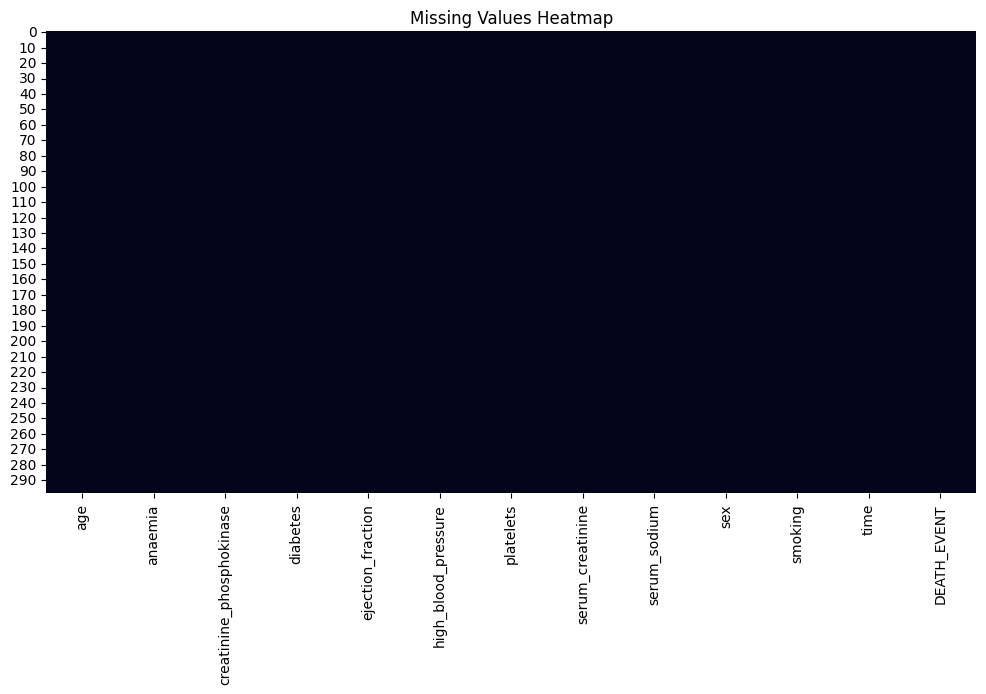

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

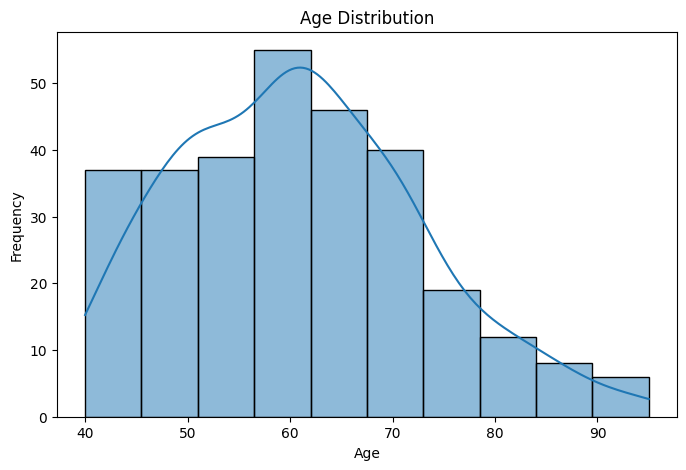

In [4]:
plt.figure(figsize=(8, 5))

sns.histplot(df["age"], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

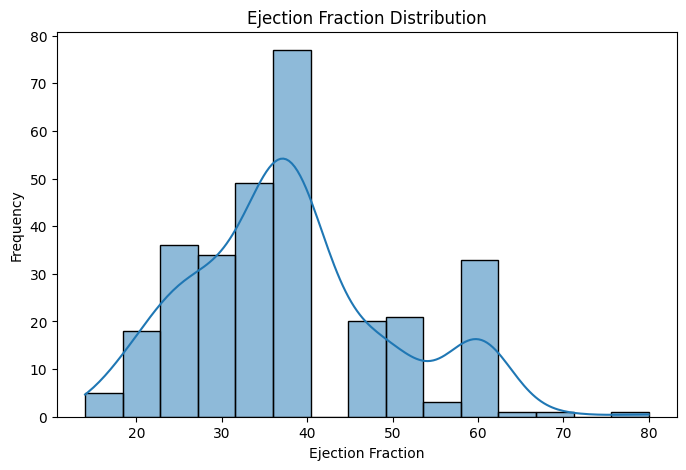

In [5]:
plt.figure(figsize=(8, 5))

sns.histplot(df["ejection_fraction"], kde=True)

plt.title("Ejection Fraction Distribution")
plt.xlabel("Ejection Fraction")
plt.ylabel("Frequency")

plt.show()

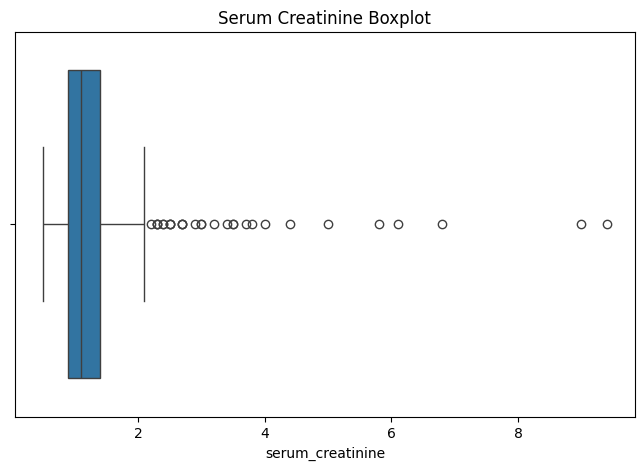

In [6]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["serum_creatinine"])

plt.title("Serum Creatinine Boxplot")

plt.show()

In [7]:
df["serum_creatinine"] = df["serum_creatinine"].fillna(
    df["serum_creatinine"].median()
)

In [8]:
df["smoking"] = df["smoking"].fillna(
    df["smoking"].mode()[0]
)

In [9]:
print(df.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [10]:
# Remoove Outliers
Q1 = df["serum_creatinine"].quantile(0.25)
Q3 = df["serum_creatinine"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df["serum_creatinine"] >= lower) &
    (df["serum_creatinine"] <= upper)
]

In [11]:
print(df[df["age"] < 0])

Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []


In [12]:
df.loc[df["age"] < 0, "age"] = df["age"].median()

In [13]:
print(df["sex"].unique())
print(df["smoking"].unique())
print(df["diabetes"].unique())

[1 0]
[0 1]
[0 1]


In [14]:
def age_group(age):
    if age < 40:
        return "<40"
    elif age <= 60:
        return "40-60"
    else:
        return ">60"

df["age_group"] = df["age"].apply(age_group)

In [15]:
df[["age", "age_group"]].head(10)

,age,age_group
0,75.0,>60
1,55.0,40-60
2,65.0,>60
3,50.0,40-60
5,90.0,>60
6,75.0,>60
7,60.0,40-60
8,65.0,>60
11,62.0,>60
12,45.0,40-60


In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["ejection_fraction_norm", "serum_creatinine_norm"]] = scaler.fit_transform(
    df[["ejection_fraction", "serum_creatinine"]]
)

In [17]:
df["risk_score"] = (
    df["ejection_fraction_norm"] *
    df["serum_creatinine_norm"]
)

In [18]:
# encode categorical variable
df = pd.get_dummies(
    df,
    columns=["age_group"],
    drop_first=True
)

In [19]:
df = pd.get_dummies(
    df,
    columns=["sex", "smoking"],
    drop_first=True
)

In [20]:
# normalize feature
from sklearn.preprocessing import MinMaxScaler

In [21]:
numeric_cols = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

In [22]:
scaler = MinMaxScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [23]:
df[numeric_cols].describe()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000
mean,0.371605,0.072276,0.367003,0.291702,0.397616,0.682222,0.462726
std,0.218401,0.125532,0.178188,0.118681,0.211494,0.119313,0.274391
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.181818,0.012035,0.242424,0.228391,0.250000,0.628571,0.258007
50%,0.363636,0.029051,0.363636,0.288833,0.375000,0.685714,0.412811
75%,0.540909,0.070489,0.469697,0.337799,0.500000,0.771429,0.717972
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [24]:
before_stats = df[numeric_cols].agg(
    ["mean", "median", "std"]
)

print(before_stats)

             age  creatinine_phosphokinase  ejection_fraction  platelets  \
mean    0.371605                  0.072276           0.367003   0.291702   
median  0.363636                  0.029051           0.363636   0.288833   
std     0.218401                  0.125532           0.178188   0.118681   

        serum_creatinine  serum_sodium      time  
mean            0.397616      0.682222  0.462726  
median          0.375000      0.685714  0.412811  
std             0.211494      0.119313  0.274391  


In [25]:
df_original = df.copy()

In [26]:
before_stats = df_original[numeric_cols].agg(
    ["mean", "median", "std"]
)

In [27]:
after_stats = df[numeric_cols].agg(
    ["mean", "median", "std"]
)

print(after_stats)

             age  creatinine_phosphokinase  ejection_fraction  platelets  \
mean    0.371605                  0.072276           0.367003   0.291702   
median  0.363636                  0.029051           0.363636   0.288833   
std     0.218401                  0.125532           0.178188   0.118681   

        serum_creatinine  serum_sodium      time  
mean            0.397616      0.682222  0.462726  
median          0.375000      0.685714  0.412811  
std             0.211494      0.119313  0.274391  


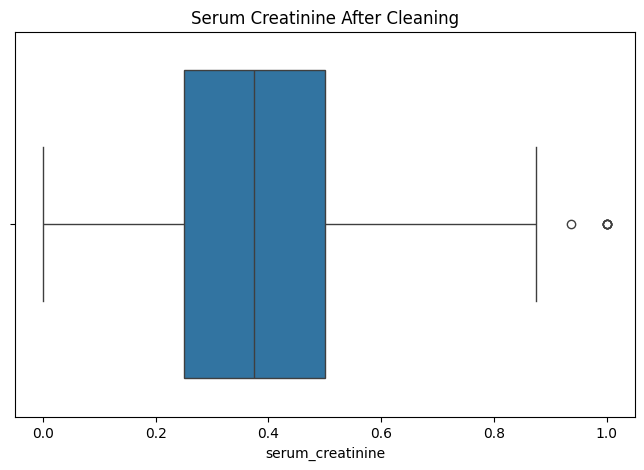

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["serum_creatinine"])

plt.title("Serum Creatinine After Cleaning")

plt.show()

In [29]:
print(df.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
time                        0
DEATH_EVENT                 0
ejection_fraction_norm      0
serum_creatinine_norm       0
risk_score                  0
age_group_>60               0
sex_1                       0
smoking_1                   0
dtype: int64


In [30]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0
